### d-prime and the ROC curve
Edit the numbers marked `👈` and re-run.

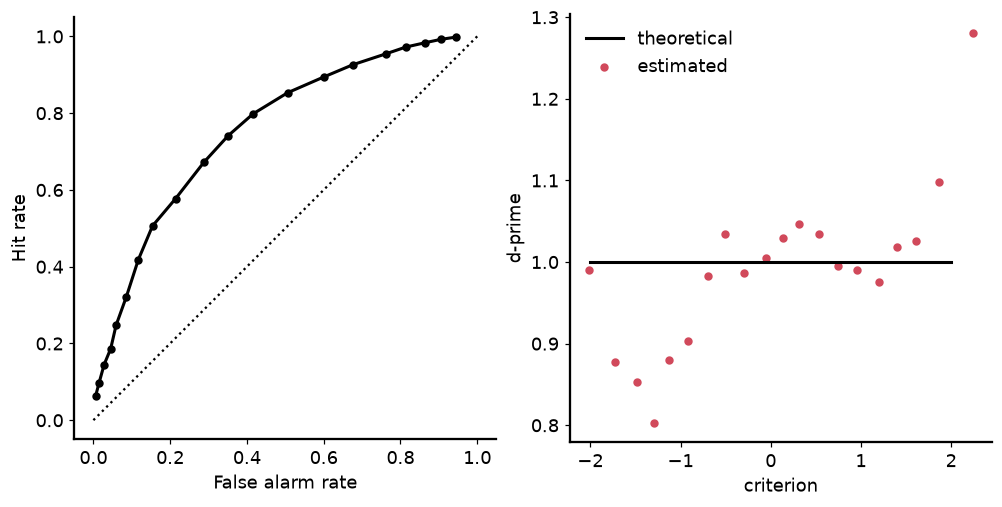

In [1]:
# (hide matplotlib's harmless one-time "building the font cache" message)
import logging; logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)

import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.dpi": 110, "font.size": 12, "axes.titlesize": 12,
    "axes.titleweight": "semibold", "axes.linewidth": 1.5,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": False, "legend.frameon": False,
})
NOISE  = "#4c6ef5"   # signal-absent (noise) trials
SIGNAL = "#d1495b"   # signal-present trials
CRIT   = "#333333"   # criterion / theory lines

from scipy.stats import norm

# back to observer 1's distributions
ntrials         = 2000    # 👈 TASK 3: try halving and doubling this
psignal         = 0.5
signal_strength = 1       # 👈 TASK 2: change this...
noise_mean, noise_sd = -0.5, 1   # 👈 ...and (separately) this noise_sd

rng = np.random.default_rng()
n_noise = round(ntrials * (1 - psignal))
noise = rng.standard_normal(ntrials) * noise_sd + noise_mean
noise_samps  = noise[:n_noise]
signal_samps = noise[n_noise:] + signal_strength

# hit-rate and false-alarm-rate at each of 20 criteria
these_criteria = np.linspace(-2, 2, 20)
hit_rates = np.array([np.mean(signal_samps > c) for c in these_criteria])
fa_rates  = np.array([np.mean(noise_samps  > c) for c in these_criteria])

# d-prime and criterion, calculated from the rates
d_primes = norm.ppf(hit_rates) - norm.ppf(fa_rates)
criteria_calculated = 0.5 * (norm.ppf(hit_rates) + norm.ppf(fa_rates))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 4.5), constrained_layout=True)

# left: the ROC curve
ax1.plot(fa_rates, hit_rates, color="k", lw=2)
ax1.scatter(fa_rates, hit_rates, 20, color="k")
ax1.plot([0, 1], [0, 1], color="k", ls=":")
ax1.set(xlabel="False alarm rate", ylabel="Hit rate")
ax1.set_aspect("equal")

# right: estimated d-prime vs theoretical (signal_strength / noise_sd)
ax2.plot(these_criteria, np.full(20, signal_strength / noise_sd), color="k", lw=2,
         label="theoretical")
ax2.scatter(criteria_calculated, d_primes, 20, color=SIGNAL, label="estimated")
ax2.set(xlabel="criterion", ylabel="d-prime")
ax2.legend()
plt.show()
